In [1]:
import os, random, time, json
import numpy as np

import torch
print("Python:", os.sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

Python: 3.11.13
Torch: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4


device(type='cuda')

In [2]:
try:
    import torch_geometric
    from torch_geometric.nn import GCNConv
    print("torch_geometric:", torch_geometric.__version__)
    pyg_ok = True
except Exception as e:
    print("PyG import failed:", e)
    pyg_ok = False

pyg_ok

PyG import failed: No module named 'torch_geometric'


False

In [3]:
import torch, os

CUDA_TAG = f"cu{torch.version.cuda.replace('.','')}" if torch.version.cuda else "cpu"
TORCH_TAG = torch.__version__.split('+')[0]

!pip -q install torch-geometric

import torch_geometric
from torch_geometric.nn import GCNConv
print("torch_geometric:", torch_geometric.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00a 0:00:01
torch_geometric: 2.7.0


In [4]:
import os, math, json, random, time
import numpy as np
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [5]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [6]:
def make_graph(graph_type: str, n: int, seed: int, pe: float = 0.3):
    rng = np.random.default_rng(seed)
    if graph_type == "line":
        g = nx.path_graph(n)
    elif graph_type == "star":
        g = nx.star_graph(n - 1)
    elif graph_type == "erdos":
        g = nx.erdos_renyi_graph(n, pe, seed=int(rng.integers(0, 10**9)))
        if not nx.is_connected(g):
            comps = list(nx.connected_components(g))
            for i in range(len(comps) - 1):
                u = next(iter(comps[i]))
                v = next(iter(comps[i + 1]))
                g.add_edge(u, v)
    else:
        raise ValueError("unknown graph_type")
    return g

def graph_to_edge_index(g: nx.Graph, device):
    edges = list(g.edges())
    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
        return edge_index
    e = np.array(edges, dtype=np.int64)
    rev = e[:, ::-1]
    e2 = np.vstack([e, rev])
    edge_index = torch.tensor(e2.T, dtype=torch.long, device=device)
    return edge_index

def graph_degree(g: nx.Graph):
    n = g.number_of_nodes()
    deg = np.array([g.degree[i] for i in range(n)], dtype=np.float32)
    return deg

In [7]:
class AoIEnv:
    def __init__(self, g: nx.Graph, p: float = 0.8, max_steps: int = 50, seed: int = 0):
        self.g = g
        self.n = g.number_of_nodes()
        self.p = float(p)
        self.max_steps = int(max_steps)
        self.rng = np.random.default_rng(seed)
        self.edge_index = graph_to_edge_index(g, device)
        self.deg = graph_degree(g)
        self.deg_norm = self.deg / (self.deg.max() + 1e-8)
        self.nei = [list(g.neighbors(i)) for i in range(self.n)]
        self.t = 0
        self.a = None

    @property
    def action_n(self):
        return self.n

    def reset(self):
        self.t = 0
        self.a = self.rng.integers(low=0, high=11, size=(self.n,)).astype(np.float32)
        return self.a.copy()

    def step(self, action: int):
        a = self.a.copy()
        a = a + 1.0

        success = (self.rng.random() < self.p)
        if success:
            a[action] = 0.0
            for j in self.nei[action]:
                if self.rng.random() < self.p:
                    a[j] = 0.0

        self.t += 1
        self.a = a

        r = -float(a.mean())
        done = (self.t >= self.max_steps)
        info = {"avg_aoi": float(a.mean()), "success": bool(success)}
        return a.copy(), r, done, info

    def pyg_data(self, aoi_state_np):
        a = aoi_state_np.astype(np.float32)
        a_norm = a / (a.max() + 1e-8)
        x = np.stack([a_norm, self.deg_norm], axis=1).astype(np.float32)
        x = torch.tensor(x, dtype=torch.float32, device=device)
        return Data(x=x, edge_index=self.edge_index)

In [8]:
def random_policy(env: AoIEnv, state):
    return random.randrange(env.action_n)

def greedy_policy(env: AoIEnv, state):
    return int(np.argmax(state))

def degree_weighted_policy(env: AoIEnv, state):
    score = env.deg * state
    return int(np.argmax(score))

def rollout(env: AoIEnv, policy_fn, episodes: int = 50):
    ms = []
    rs = []
    for _ in range(episodes):
        s = env.reset()
        ep_aoi = []
        ep_r = 0.0
        for _t in range(env.max_steps):
            a = policy_fn(env, s)
            ns, r, done, info = env.step(a)
            ep_aoi.append(info["avg_aoi"])
            ep_r += r
            s = ns
            if done:
                break
        ms.append(float(np.mean(ep_aoi)))
        rs.append(float(ep_r))
    return float(np.mean(ms)), float(np.std(ms)), float(np.mean(rs))

In [9]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = int(capacity)
        self.buf = []
        self.i = 0

    def __len__(self):
        return len(self.buf)

    def push(self, data):
        if len(self.buf) < self.capacity:
            self.buf.append(data)
        else:
            self.buf[self.i] = data
            self.i = (self.i + 1) % self.capacity

    def sample(self, batch_size: int):
        idx = np.random.randint(0, len(self.buf), size=(batch_size,))
        batch = [self.buf[i] for i in idx]
        return batch

class GNNQNet(nn.Module):
    def __init__(self, in_dim=2, hidden=64):
        super().__init__()
        self.c1 = GCNConv(in_dim, hidden)
        self.c2 = GCNConv(hidden, hidden)
        self.out = nn.Linear(hidden, 1)

    def forward(self, data: Data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.c1(x, edge_index))
        x = F.relu(self.c2(x, edge_index))
        q = self.out(x).squeeze(-1)
        return q

In [10]:
def batch_from(env_list, state_list_np):
    datas = [env.pyg_data(s) for env, s in zip(env_list, state_list_np)]
    return Batch.from_data_list(datas)

@torch.no_grad()
def act_eps_greedy(q_net, env: AoIEnv, state_np, eps: float):
    if random.random() < eps:
        return random.randrange(env.action_n)
    data = env.pyg_data(state_np)
    q = q_net(data)
    return int(torch.argmax(q).item())

def train_generalized_gnn_dqn(
    episodes=600,
    n=10,
    pe_train=0.3,
    p=0.8,
    max_steps=50,
    gamma=0.99,
    lr=1e-3,
    hidden=64,
    batch_size=64,
    buffer_size=30000,
    warmup=2000,
    target_update=400,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    seed=123
):
    set_seed(seed)
    q_net = GNNQNet(in_dim=2, hidden=hidden).to(device)
    target = GNNQNet(in_dim=2, hidden=hidden).to(device)
    target.load_state_dict(q_net.state_dict())
    target.eval()

    opt = optim.Adam(q_net.parameters(), lr=lr)
    rb = ReplayBuffer(buffer_size)

    eps = eps_start
    total_steps = 0
    ep_mean_aoi = []

    for ep in range(episodes):
        g = make_graph("erdos", n, seed=seed + 10_000 + ep, pe=pe_train)
        env = AoIEnv(g, p=p, max_steps=max_steps, seed=seed + 20_000 + ep)
        s = env.reset()
        aoi_trace = []

        for t in range(max_steps):
            a = act_eps_greedy(q_net, env, s, eps)
            ns, r, done, info = env.step(a)
            rb.push((env, s.copy(), a, float(r), ns.copy(), float(done)))
            s = ns
            aoi_trace.append(info["avg_aoi"])

            if len(rb) >= warmup:
                batch = rb.sample(batch_size)
                envs = [b[0] for b in batch]
                bs = [b[1] for b in batch]
                ba = torch.tensor([b[2] for b in batch], dtype=torch.long, device=device)
                br = torch.tensor([b[3] for b in batch], dtype=torch.float32, device=device)
                bns = [b[4] for b in batch]
                bd = torch.tensor([b[5] for b in batch], dtype=torch.float32, device=device)

                batch_s = batch_from(envs, bs)
                q_all = q_net(batch_s).view(batch_size, n)
                q_sa = q_all[torch.arange(batch_size, device=device), ba]

                with torch.no_grad():
                    batch_ns = batch_from(envs, bns)
                    q_next = target(batch_ns).view(batch_size, n)
                    q_next_max = q_next.max(dim=1).values
                    y = br + gamma * (1.0 - bd) * q_next_max

                loss = F.smooth_l1_loss(q_sa, y)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q_net.parameters(), 5.0)
                opt.step()

                total_steps += 1
                if total_steps % target_update == 0:
                    target.load_state_dict(q_net.state_dict())

            if done:
                break

        eps = max(eps_end, eps * eps_decay)
        ep_mean_aoi.append(float(np.mean(aoi_trace)))

        if (ep + 1) % 50 == 0:
            print("ep", ep + 1, "eps", round(eps, 3), "mean_aoi_ep", round(ep_mean_aoi[-1], 3))

    return q_net, {"ep_mean_aoi": ep_mean_aoi}

In [11]:
def eval_suite(q_net, n=10, p=0.8, max_steps=50):
    @torch.no_grad()
    def gnn_policy(env: AoIEnv, state):
        data = env.pyg_data(state)
        q = q_net(data)
        return int(torch.argmax(q).item())

    suites = {
        "line": [910, 911, 912, 913, 914],
        "star": [920, 921, 922, 923, 924],
        "erdos_new": [900, 901, 902, 903, 904]
    }

    out = {}
    for name, seeds in suites.items():
        rows = {}
        for pol_name, pol in {
            "random": random_policy,
            "greedy": greedy_policy,
            "degree_weighted": degree_weighted_policy,
            "gnn": gnn_policy
        }.items():
            ms = []
            for sd in seeds:
                g = make_graph("erdos" if name == "erdos_new" else name, n, seed=sd, pe=0.3)
                env = AoIEnv(g, p=p, max_steps=max_steps, seed=sd + 10000)
                m, s, _ = rollout(env, pol, episodes=40)
                ms.append(m)
            rows[pol_name] = {"mean": float(np.mean(ms)), "std": float(np.std(ms))}
        out[name] = rows
    return out

In [12]:
q_net, train_log = train_generalized_gnn_dqn(episodes=600, n=10, pe_train=0.3, p=0.8, max_steps=50, seed=123)
torch.save(q_net.state_dict(), "artifacts/gnn_final.pt")

with open("artifacts/train_log.json", "w") as f:
    json.dump(train_log, f, indent=2)

results = eval_suite(q_net, n=10, p=0.8, max_steps=50)
with open("artifacts/final_results.json", "w") as f:
    json.dump(results, f, indent=2)

results

ep 50 eps 0.778 mean_aoi_ep 3.314
ep 100 eps 0.606 mean_aoi_ep 2.422
ep 150 eps 0.471 mean_aoi_ep 2.06
ep 200 eps 0.367 mean_aoi_ep 3.366
ep 250 eps 0.286 mean_aoi_ep 2.384
ep 300 eps 0.222 mean_aoi_ep 2.58
ep 350 eps 0.173 mean_aoi_ep 1.768
ep 400 eps 0.135 mean_aoi_ep 2.374
ep 450 eps 0.105 mean_aoi_ep 1.848
ep 500 eps 0.082 mean_aoi_ep 1.472
ep 550 eps 0.063 mean_aoi_ep 1.778
ep 600 eps 0.05 mean_aoi_ep 1.69


{'line': {'random': {'mean': 4.282449998641014, 'std': 0.06033464208935704},
  'greedy': {'mean': 2.822789996790886, 'std': 0.04062884845569388},
  'degree_weighted': {'mean': 2.732549994838238, 'std': 0.03874409768015781},
  'gnn': {'mean': 5.32444999961853, 'std': 0.10016949343435187}},
 'star': {'random': {'mean': 5.302710001070798, 'std': 0.1299236766264502},
  'greedy': {'mean': 4.7001299897708, 'std': 0.04958399784113509},
  'degree_weighted': {'mean': 1.7650199899569157, 'std': 0.03781520246745061},
  'gnn': {'mean': 0.5808900037124752, 'std': 0.018855062789525635}},
 'erdos_new': {'random': {'mean': 3.245359998212755,
   'std': 0.45830529940284465},
  'greedy': {'mean': 2.4942899954020974, 'std': 0.19237752987745305},
  'degree_weighted': {'mean': 2.0891199963748455, 'std': 0.29094775737584005},
  'gnn': {'mean': 2.2227599958479405, 'std': 0.3277296210326917}}}

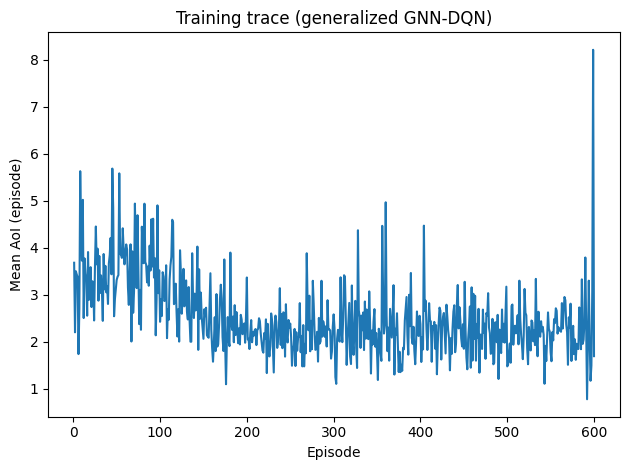

In [13]:
y = train_log["ep_mean_aoi"]
plt.figure()
plt.plot(np.arange(1, len(y)+1), y)
plt.xlabel("Episode")
plt.ylabel("Mean AoI (episode)")
plt.title("Training trace (generalized GNN-DQN)")
plt.tight_layout()
plt.savefig("figures/train_trace.png", dpi=200)
plt.show()

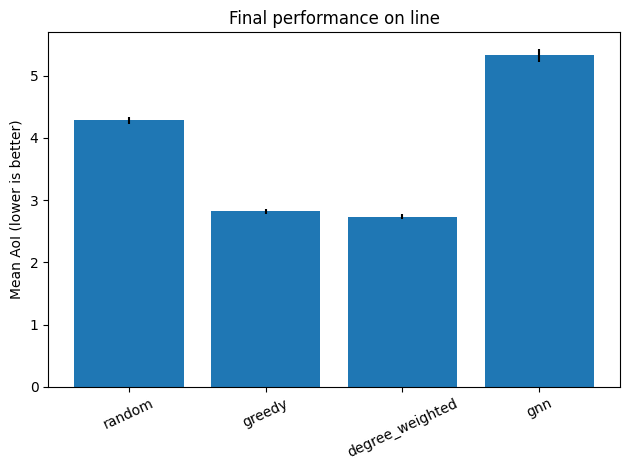

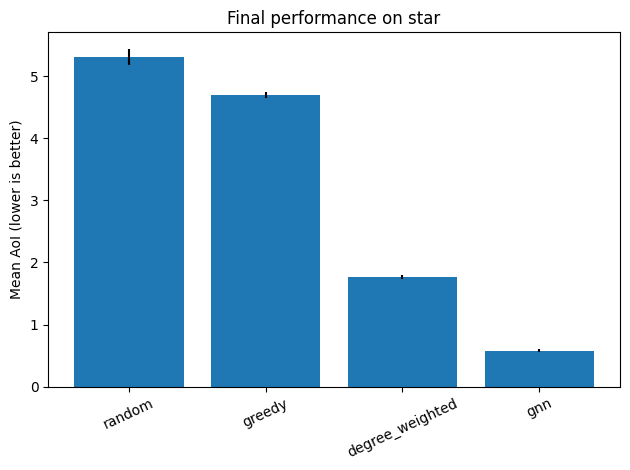

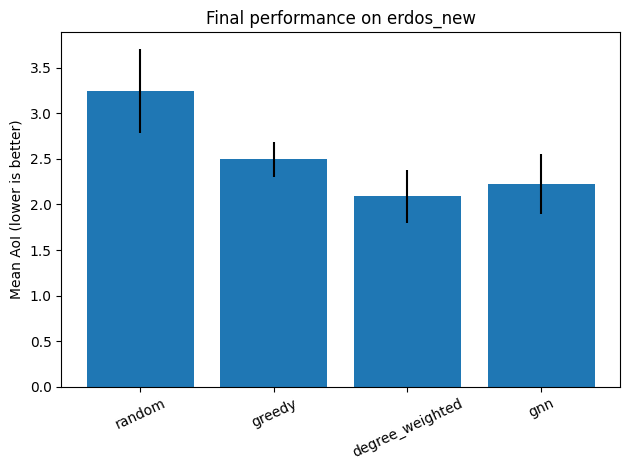

In [14]:
def barplot_family(family_key, results):
    keys = ["random", "greedy", "degree_weighted", "gnn"]
    means = [results[family_key][k]["mean"] for k in keys]
    stds  = [results[family_key][k]["std"]  for k in keys]
    plt.figure()
    plt.bar(keys, means, yerr=stds)
    plt.ylabel("Mean AoI (lower is better)")
    plt.title(f"Final performance on {family_key}")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(f"figures/perf_{family_key}.png", dpi=200)
    plt.show()

for fam in ["line", "star", "erdos_new"]:
    barplot_family(fam, results)

### it turned out to be a really strong solution for star and a normal one for erdos_new, but the failure on line is almost certainly due to the fact that I trained only on Erdos distribution, and line is a different mode

In [21]:
import torch
import numpy as np
from torch_geometric.data import Data, Batch

def pyg_from_state(edge_index, deg, state, device):
    a = torch.tensor(state, dtype=torch.float32, device=device).view(-1, 1)
    d = torch.tensor(deg, dtype=torch.float32, device=device).view(-1, 1)
    x = torch.cat([a, d], dim=1)
    ei = torch.tensor(edge_index, dtype=torch.long, device=device)
    return Data(x=x, edge_index=ei)

def batch_from_transitions(edge_index_list, deg_list, state_list, device):
    data_list = [pyg_from_state(ei, dg, st, device) for ei, dg, st in zip(edge_index_list, deg_list, state_list)]
    return Batch.from_data_list(data_list)

In [22]:
import random
from collections import deque

class ReplayGraphBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, edge_index, deg, s, a, r, ns, done):
        self.buf.append((edge_index, deg, s.copy(), int(a), float(r), ns.copy(), float(done)))

    def __len__(self):
        return len(self.buf)

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        ei, dg, s, a, r, ns, d = zip(*batch)
        return list(ei), list(dg), list(s), np.array(a), np.array(r), list(ns), np.array(d)

In [23]:
import networkx as nx

def graph_to_edge_index_and_deg(G):
    n = G.number_of_nodes()
    edges = []
    for u, v in G.edges():
        edges.append((u, v))
        edges.append((v, u))
    if len(edges) == 0:
        edge_index = np.zeros((2, 0), dtype=np.int64)
    else:
        edge_index = np.array(edges, dtype=np.int64).T
    deg = np.array([G.degree(i) for i in range(n)], dtype=np.float32)
    return edge_index, deg

In [24]:
import torch.nn.functional as F
import torch.optim as optim

def sample_graph_family(rng):
    u = rng.random()
    if u < 0.25:
        return "line", None
    if u < 0.50:
        return "star", None
    pe = float(rng.uniform(0.15, 0.55))
    return "erdos", pe

def make_env_for_family(fam, pe, seed, n=10, p=0.8, max_steps=50):
    if fam == "erdos":
        G = make_graph("erdos", n, seed=seed, pe=pe)
    else:
        G = make_graph(fam, n, seed=seed)
    env = AoIEnv(G, p=p, max_steps=max_steps, seed=seed)
    return env, G

def train_mixed_gnn_dqn_v2(
    episodes=800,
    n=10,
    p=0.8,
    max_steps=50,
    gamma=0.99,
    lr=1e-3,
    hidden=64,
    batch_size=64,
    buffer_size=40000,
    warmup=3000,
    target_update=600,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.996,
    seed=123
):
    set_seed(seed)
    rng = np.random.default_rng(seed + 777)

    q_net = GNNQNet(in_dim=2, hidden=hidden).to(device)
    target = GNNQNet(in_dim=2, hidden=hidden).to(device)
    target.load_state_dict(q_net.state_dict())
    target.eval()

    opt = optim.Adam(q_net.parameters(), lr=lr)
    rb = ReplayGraphBuffer(buffer_size)

    eps = eps_start
    total_steps = 0
    ep_mean_aoi = []
    ep_family = []

    for ep in range(episodes):
        fam, pe = sample_graph_family(rng)
        env, G = make_env_for_family(fam, pe, seed=seed + 10_000 + ep, n=n, p=p, max_steps=max_steps)
        edge_index, deg = graph_to_edge_index_and_deg(G)

        s = env.reset()
        aoi_trace = []

        for t in range(max_steps):
            if random.random() < eps:
                a = random.randrange(env.action_n)
            else:
                with torch.no_grad():
                    data = pyg_from_state(edge_index, deg, s, device)
                    q = q_net(data)
                    a = int(torch.argmax(q).item())

            ns, r, done, info = env.step(a)
            rb.push(edge_index, deg, s, a, r, ns, done)
            s = ns
            aoi_trace.append(info["avg_aoi"])

            if len(rb) >= warmup:
                bei, bdg, bs, ba, br, bns, bdone = rb.sample(batch_size)

                batch_s = batch_from_transitions(bei, bdg, bs, device)
                q_all = q_net(batch_s).view(batch_size, n)
                ba_t = torch.tensor(ba, dtype=torch.long, device=device)
                q_sa = q_all[torch.arange(batch_size, device=device), ba_t]

                with torch.no_grad():
                    batch_ns = batch_from_transitions(bei, bdg, bns, device)
                    q_next = target(batch_ns).view(batch_size, n)
                    q_next_max = q_next.max(dim=1).values
                    br_t = torch.tensor(br, dtype=torch.float32, device=device)
                    bd_t = torch.tensor(bdone, dtype=torch.float32, device=device)
                    y = br_t + gamma * (1.0 - bd_t) * q_next_max

                loss = F.smooth_l1_loss(q_sa, y)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q_net.parameters(), 5.0)
                opt.step()

                total_steps += 1
                if total_steps % target_update == 0:
                    target.load_state_dict(q_net.state_dict())

            if done:
                break

        eps = max(eps_end, eps * eps_decay)
        ep_mean_aoi.append(float(np.mean(aoi_trace)))
        ep_family.append(fam)

        if (ep + 1) % 100 == 0:
            print("ep", ep + 1, "eps", round(eps, 3), "fam", fam, "mean_aoi_ep", round(ep_mean_aoi[-1], 3))

    return q_net, {"ep_mean_aoi": ep_mean_aoi, "ep_family": ep_family}

In [25]:
@torch.no_grad()
def gnn_policy_factory(q_net, G):
    edge_index, deg = graph_to_edge_index_and_deg(G)
    def pol(env, state):
        data = pyg_from_state(edge_index, deg, state, device)
        q = q_net(data)
        return int(torch.argmax(q).item())
    return pol

def eval_suite_strict_v2(q_net, n=10, p=0.8, max_steps=50):
    suites = {
        "line": [910, 911, 912, 913, 914],
        "star": [920, 921, 922, 923, 924],
        "erdos_new": [900, 901, 902, 903, 904],
    }

    out = {}
    for name, seeds in suites.items():
        rows = {}
        for pol_name in ["random", "greedy", "degree_weighted", "gnn"]:
            ms = []
            for sd in seeds:
                if name == "erdos_new":
                    env = make_env("erdos", seed=sd, num_nodes=n, p=p, max_steps=max_steps)
                    G = env.G
                else:
                    env = make_env(name, seed=sd, num_nodes=n, p=p, max_steps=max_steps)
                    G = env.G

                if pol_name == "random":
                    pol = random_policy
                elif pol_name == "greedy":
                    pol = greedy_stale_policy
                elif pol_name == "degree_weighted":
                    pol = degree_weighted_policy
                else:
                    pol = gnn_policy_factory(q_net, G)

                m, _ = evaluate(env, pol, episodes=40)
                ms.append(m)

            rows[pol_name] = {"mean": float(np.mean(ms)), "std": float(np.std(ms))}
        out[name] = rows
    return out

In [26]:
import os, torch, random, numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("artifacts", exist_ok=True)

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(123)
device

device(type='cuda')

In [27]:
q_net, logs = train_mixed_gnn_dqn_v2(
    episodes=800,
    n=10,
    p=0.8,
    max_steps=50,
    gamma=0.99,
    lr=1e-3,
    hidden=64,
    batch_size=64,
    buffer_size=40000,
    warmup=3000,
    target_update=600,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.996,
    seed=123
)

ep 100 eps 0.67 fam erdos mean_aoi_ep 2.004
ep 200 eps 0.449 fam erdos mean_aoi_ep 3.682
ep 300 eps 0.3 fam erdos mean_aoi_ep 6.534
ep 400 eps 0.201 fam erdos mean_aoi_ep 5.408
ep 500 eps 0.135 fam erdos mean_aoi_ep 1.962
ep 600 eps 0.09 fam erdos mean_aoi_ep 9.216
ep 700 eps 0.06 fam erdos mean_aoi_ep 2.226
ep 800 eps 0.05 fam line mean_aoi_ep 3.78


In [38]:
def evaluate(env, policy_fn, episodes=40, seed0=0):
    means = []
    traces = []
    for k in range(episodes):
        try:
            s = env.reset(seed=seed0 + k)
        except TypeError:
            s = env.reset()

        done = False
        ep_sum_aoi = 0.0
        ep_steps = 0

        while not done:
            a = policy_fn(env, s)
            out = env.step(a)

            if len(out) == 5:
                ns, r, terminated, truncated, info = out
                done = bool(terminated or truncated)
            else:
                ns, r, done, info = out

            if isinstance(info, dict) and ("avg_aoi" in info):
                ep_sum_aoi += float(info["avg_aoi"])
            else:
                ep_sum_aoi += float(np.mean(ns))

            ep_steps += 1
            s = ns

        mean_aoi_ep = ep_sum_aoi / max(ep_steps, 1)
        means.append(mean_aoi_ep)
        traces.append(ep_steps)

    return float(np.mean(means)), {"per_episode_mean_aoi": means, "ep_steps": traces}

def eval_suite_strict_v2(q_net, n=10, p=0.8, max_steps=50):
    suites = {
        "line": [910, 911, 912, 913, 914],
        "star": [920, 921, 922, 923, 924],
        "erdos_new": [900, 901, 902, 903, 904],
    }

    out = {}
    for name, seeds in suites.items():
        rows = {}
        for pol_name in ["random", "greedy", "degree_weighted", "gnn"]:
            ms = []
            for sd in seeds:
                if name == "erdos_new":
                    env = make_env("erdos", seed=sd, p=p, max_steps=max_steps)
                    G = env.g
                else:
                    env = make_env(name, seed=sd, p=p, max_steps=max_steps)
                    G = env.g

                if pol_name == "random":
                    pol = random_policy
                elif pol_name == "greedy":
                    pol = greedy_policy
                elif pol_name == "degree_weighted":
                    pol = degree_weighted_policy
                else:
                    pol = gnn_policy_factory(q_net, G)

                m, _ = evaluate(env, pol, episodes=40)
                ms.append(m)

            rows[pol_name] = {"mean": float(np.mean(ms)), "std": float(np.std(ms))}
        out[name] = rows
    return out

In [39]:
results = eval_suite_strict_v2(q_net, n=10, p=0.8, max_steps=50)
results

{'line': {'random': {'mean': 4.1816999990224835, 'std': 0.03831959274182534},
  'greedy': {'mean': 2.822789996790886, 'std': 0.04062884845569388},
  'degree_weighted': {'mean': 2.732549994838238, 'std': 0.03874409768015781},
  'gnn': {'mean': 3.9204099986553187, 'std': 0.0405633494266548}},
 'star': {'random': {'mean': 5.459700002198666, 'std': 0.10277992385600793},
  'greedy': {'mean': 4.7001299897708, 'std': 0.04958399784113509},
  'degree_weighted': {'mean': 1.7650199899569157, 'std': 0.03781520246745061},
  'gnn': {'mean': 0.579370004054159, 'std': 0.0349372095433817}},
 'erdos_new': {'random': {'mean': 3.2336000005081296,
   'std': 0.41240844978500957},
  'greedy': {'mean': 2.4942899954020974, 'std': 0.19237752987745305},
  'degree_weighted': {'mean': 2.0891199963748455, 'std': 0.29094775737584005},
  'gnn': {'mean': 7.3172900022387495, 'std': 2.7892451704257266}}}

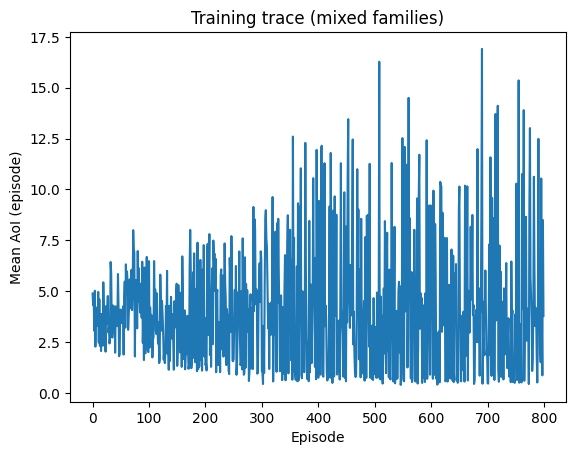

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(logs["ep_mean_aoi"])
plt.title("Training trace (mixed families)"); plt.xlabel("Episode"); plt.ylabel("Mean AoI (episode)")
plt.show()